# Ray Unit 2 - Distributed Hyperparameter Optimization


We've done HPO before. In this notebook we rebuild that workflow on a Ray cluster, one distributed-systems idea at a time.

## Setup

Run this notebook with the `22971-ray` kernel.

In [91]:
import random
import time

import numpy as np
import optuna
import pandas as pd
import ray
import xgboost as xgb
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

# silence Optuna:
optuna.logging.set_verbosity(optuna.logging.WARNING)





ray.shutdown()
ray.init(ignore_reinit_error=True, include_dashboard=False, log_to_driver=False)

print("Ray resources:", ray.cluster_resources())

2026-03-27 14:26:59,090	INFO worker.py:2013 -- Started a local Ray instance.


Ray resources: {'node:127.0.0.1': 1.0, 'object_store_memory': 1683811123.0, 'memory': 3928892621.0, 'node:__internal_head__': 1.0, 'CPU': 12.0}


## Data ingestion

We'll use the same breast cancer data we've used before. 

This time we'll do 3-fold CV:
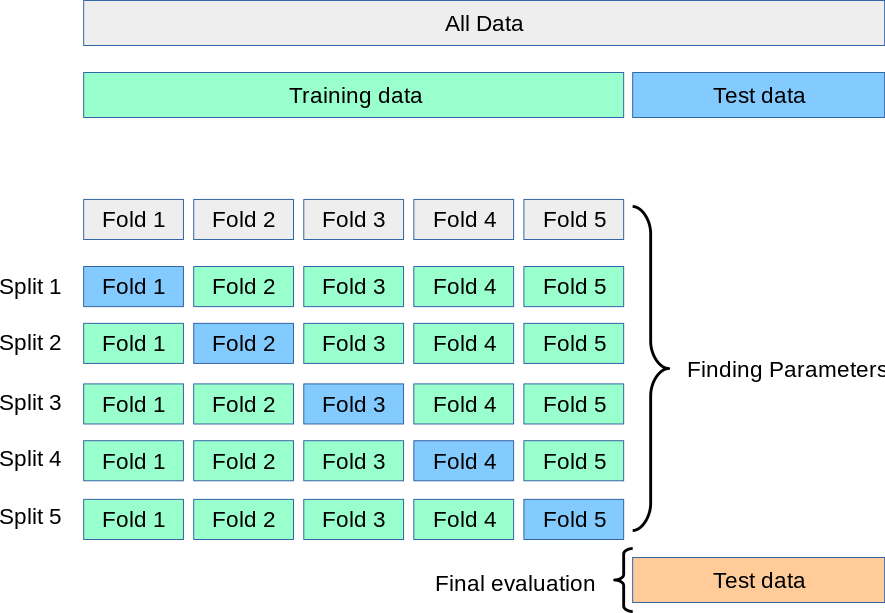
Source: [sklearn docs](https://scikit-learn.org/stable/modules/cross_validation.html)

**Zero-copy note:**
- We will store the full NumPy arrays once in the object store.
- Each split/fold carries only integer row ids (indices).
- All workers on a node will gather train \ validation rows from a single shared memory location.

This only works with NumPy ndarrays.

In [92]:
SEED = 0
NUM_BOOST_ROUND = 60
TEST_SIZE = 0.20
N_FOLDS = 3

X, y = load_breast_cancer(return_X_y=True)
# X: numeric ndarray, y: 0=malignant, 1=benign

all_idx = np.arange(X.shape[0])
trainval_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,     #Same pct of 0s and 1s in both sets
)

X_ref = ray.put(X)
y_ref = ray.put(y)


def make_index_bundle(train_idx, valid_idx, fold_id=None):
    bundle = {
        "X_ref": X_ref,
        "y_ref": y_ref,
        "train_idx_ref": ray.put(train_idx),
        "valid_idx_ref": ray.put(valid_idx),
        "fold_id": fold_id
    }
    return bundle


cv_labels = y[trainval_idx]
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_sizes = []
fold_bundles = []
for fold_id, (train_pos, valid_pos) in enumerate(skf.split(trainval_idx, cv_labels)):
    train_idx = trainval_idx[train_pos]
    valid_idx = trainval_idx[valid_pos]
    fold_sizes.append((train_idx.size, valid_idx.size))
    fold_bundles.append(make_index_bundle(train_idx, valid_idx, fold_id=fold_id))

fold_bundle_refs = [ray.put(bundle) for bundle in fold_bundles]

print(f"trainval rows        : {trainval_idx.size}")
print(f"test rows            : {test_idx.size}")
print("cv fold sizes        :", fold_sizes)


trainval rows        : 455
test rows            : 114
cv fold sizes        : [(303, 152), (303, 152), (304, 151)]


## Helper functions

ML and HPO plumbing.

In [93]:
DEMO_PARAMS = {
    "max_depth": 4,
    "eta": 0.08,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "lambda": 0.5,
}

def suggest_xgb_params(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "eta": trial.suggest_float("eta", 1e-2, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
    }


def build_xgb_params(sampled_params, seed=SEED):
    return {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "verbosity": 0,
        "seed": seed,
        **sampled_params,
    }
# Same RNG for all Optuna trials makes sense. 
# In other use cases this might be problematic.
# Watch out, RNG in distributed systems is tricky.

def resolve_fold(bundle):
    X_shared = ray.get(bundle["X_ref"])
    y_shared = ray.get(bundle["y_ref"])
    train_idx = ray.get(bundle["train_idx_ref"])
    valid_idx = ray.get(bundle["valid_idx_ref"])
    return (
        X_shared[train_idx],
        y_shared[train_idx],
        X_shared[valid_idx],
        y_shared[valid_idx],
    )


def fit_fold(bundle, sampled_params, num_boost_round=NUM_BOOST_ROUND, seed=SEED):
    X_train, y_train, X_valid, y_valid = resolve_fold(bundle)
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    evals_result = {}
    xgb.train(
        params=build_xgb_params(sampled_params, seed=seed),
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=[(dvalid, "valid")],
        evals_result=evals_result,
        verbose_eval=False,
    )

    valid_auc = np.asarray(evals_result["valid"]["auc"], dtype=float)
    best_iteration = int(valid_auc.argmax())
    best_auc = float(valid_auc[best_iteration])
    return {
        "best_auc": best_auc,
        "best_iteration": best_iteration,
        "last_auc": float(valid_auc[-1]),
    }


def score_cv_bundles(bundle_list, sampled_params, num_boost_round=NUM_BOOST_ROUND, seed=SEED):
    fold_results = []
    for bundle in bundle_list:
        result = fit_fold(bundle, sampled_params, num_boost_round=num_boost_round, seed=seed)
        fold_results.append(
            {
                "fold_id": bundle["fold_id"],
                **result,
            }
        )
    fold_scores = [item["best_auc"] for item in fold_results]
    fold_iterations = [item["best_iteration"] for item in fold_results]
    return {
        "score": float(np.mean(fold_scores)),
        "best_iteration": int(np.round(np.mean(fold_iterations))),
        "fold_results": fold_results,
    }


def train_final_model(best_params, num_boost_round, X_data, y_data, train_idx, test_idx, seed=SEED):
    dtrainval = xgb.DMatrix(X_data[train_idx], label=y_data[train_idx])
    dtest = xgb.DMatrix(X_data[test_idx], label=y_data[test_idx])

    booster = xgb.train(
        params=build_xgb_params(best_params, seed=seed),
        dtrain=dtrainval,
        num_boost_round=num_boost_round,
        verbose_eval=False,
    )
    pred_test = booster.predict(dtest)
    return float(roc_auc_score(y_data[test_idx], pred_test))


def format_study_results_df(results_df, sort_by="score", ascending=False):
    results_df = results_df.rename(
        columns={
            "number": "trial_id",
            "value": "score",
            "user_attrs_completion_rank": "completion_rank",
            "user_attrs_best_iteration": "best_iteration",
            "user_attrs_duplicate_attempt_folds": "duplicate_attempt_folds",
            "user_attrs_duplicate_attempt_trials": "duplicate_attempt_trials",
            "params_max_depth": "max_depth",
            "params_eta": "eta",
            "params_subsample": "subsample",
            "params_colsample_bytree": "colsample_bytree",
            "params_lambda": "lambda",
        }
    )

    preferred_cols = [
        "completion_rank",
        "trial_id",
        "score",
        "best_iteration",
        "max_depth",
        "eta",
        "subsample",
        "colsample_bytree",
        "lambda",
    ]
    available_cols = [col for col in preferred_cols if col in results_df.columns]
    return results_df[available_cols].sort_values(sort_by, ascending=ascending).reset_index(drop=True)


def study_results_df(study, sort_by="score", ascending=False):
    raw_df = study.trials_dataframe(
        attrs=("number", "value", "params", "user_attrs"),
        multi_index=False,
    )
    return format_study_results_df(raw_df, sort_by=sort_by, ascending=ascending)


## 0. Local run

Nothing is distributed yet. The driver samples params, runs all three folds itself, and returns the mean CV AUC.


In [94]:
def local_objective(trial):
    params = suggest_xgb_params(trial)
    result = score_cv_bundles(fold_bundles, params)
    trial.set_user_attr("best_iteration", result["best_iteration"])
    return result["score"]


local_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
local_study.optimize(local_objective, n_trials=6)

local_results = study_results_df(local_study)
print(f"Best local CV AUC: {local_study.best_value:.5f}")
print("Best params:", local_study.best_params)
display(local_results)


Best local CV AUC: 0.99312
Best params: {'max_depth': 6, 'eta': 0.15151446654565384, 'subsample': 0.7845917449011728, 'colsample_bytree': 0.9122116705145822, 'lambda': 0.0029723346443356552}


,trial_id,score,best_iteration,max_depth,eta,subsample,colsample_bytree,lambda
0,4,0.993117,32,6,0.151514,0.784592,0.912212,0.002972
1,2,0.992650,23,5,0.060429,0.827218,0.970239,0.001924
2,0,0.992523,39,4,0.113873,0.841105,0.817953,0.049502
3,1,0.991867,37,5,0.044296,0.956709,0.985465,0.034180
4,5,0.991650,51,5,0.016284,0.977868,0.808739,0.045567
5,3,0.977855,39,2,0.010712,0.933048,0.911263,3.020290


## 1. Distributed trials

We only change one thing in this section: the driver stops evaluating CV trials itself.

The driver still owns the Optuna study, but it now:

1. samples params with `study.ask()`
2. launches one Ray task per trial
3. keeps a fixed number of trials in flight with `ray.wait()`
4. feeds completed scores back with `study.tell(...)`

Each trial task still computes its 3 folds sequentially.


In [95]:
@ray.remote(num_cpus=1)
def run_cv_trial_serial_remote(trial_id, params, fold_bundle_refs):
    fold_bundles = ray.get(fold_bundle_refs)
    result = score_cv_bundles(fold_bundles, params)
    return {
        "trial_id": trial_id,
        "score": result["score"],
        "best_iteration": result["best_iteration"],
    }

def run_distributed_cv_study(
    fold_bundle_refs,
    n_trials=6,
    max_concurrent_trials=3,
    seed=SEED,
    trial_runner=run_cv_trial_serial_remote,
):
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    in_flight = {}
    launched = 0

    def launch_one():
        trial = study.ask()
        params = suggest_xgb_params(trial)
        result_ref = trial_runner.remote(trial.number, params, fold_bundle_refs)
        in_flight[result_ref] = {
            "trial": trial,
            "params": params,
        }

    while launched < min(max_concurrent_trials, n_trials):
        launch_one()
        launched += 1


    while in_flight:
        ready_refs, _ = ray.wait(list(in_flight.keys()), num_returns=1)
        ready_ref = ready_refs[0]
        meta = in_flight.pop(ready_ref)
        result = ray.get(ready_ref)

        completion_rank = len(study.trials) - len(in_flight)
                          # completed + in_flight
        meta["trial"].set_user_attr("completion_rank", completion_rank)
        meta["trial"].set_user_attr("best_iteration", result["best_iteration"])
        study.tell(meta["trial"], result["score"])
        print(
            f"[driver] completion_rank={completion_rank} trial={result['trial_id']} "
            f"score={result['score']:.5f}",
            flush=True,
        )

        if launched < n_trials:
            launch_one()
            launched += 1


    results_df = study_results_df(study, sort_by="completion_rank", ascending=True)
    return study, results_df


In [96]:
distributed_cv_study, distributed_cv_results = run_distributed_cv_study(
    fold_bundle_refs,
    n_trials=6,
    max_concurrent_trials=3,
)
print(f"Best distributed CV AUC: {distributed_cv_study.best_value:.5f}")
display(distributed_cv_results)


[driver] completion_rank=1 trial=0 score=0.99265
[driver] completion_rank=2 trial=1 score=0.99153
[driver] completion_rank=3 trial=2 score=0.99203
[driver] completion_rank=4 trial=3 score=0.97644
[driver] completion_rank=5 trial=4 score=0.99262
[driver] completion_rank=6 trial=5 score=0.99208
Best distributed CV AUC: 0.99265


,completion_rank,trial_id,score,best_iteration,max_depth,eta,subsample,colsample_bytree,lambda
0,1,0,0.992650,34,4,0.113873,0.841105,0.817953,0.049502
1,2,1,0.991526,35,5,0.044296,0.956709,0.985465,0.034180
2,3,2,0.992034,19,5,0.060429,0.827218,0.970239,0.001924
3,4,3,0.976444,41,2,0.010712,0.933048,0.911263,3.020290
4,5,4,0.992621,36,6,0.151514,0.784592,0.912212,0.002972
5,6,5,0.992081,58,5,0.016284,0.977868,0.808739,0.045567


## 2. Nested remote tasks

In the previous implementation, the trials run in parallel but each trial itself is composed of three sequential training runs (3-fold CV). We can run these training runs in parallel as well.

Now the driver will schedule trial tasks, which in turn will schedule fold training runs:
 
`driver -> CV trial task -> fold training tasks`

In [97]:
@ray.remote(num_cpus=1)
def train_fold_remote(trial_id, fold_id, params, fold_bundle):
    t0 = time.perf_counter()
    result = fit_fold(fold_bundle, params)
    return {
        "trial_id": trial_id,
        "fold_id": fold_id,
        "worker_id": ray.get_runtime_context().get_worker_id(),
        "duration_sec": time.perf_counter() - t0,
        **result,
    }


def summarize_parallel_fold_result_refs(fold_result_refs):
    pending_refs = list(fold_result_refs)
    completion_order = []
    while pending_refs:
        ready_refs, pending_refs = ray.wait(pending_refs, num_returns=1)
        fold_result = ray.get(ready_refs[0])
        completion_order.append({
            "completion_rank": len(completion_order) + 1,
            **fold_result,
        })

    fold_scores = [item["best_auc"] for item in completion_order]
    fold_iterations = [item["best_iteration"] for item in completion_order]
    return {
        "score": float(np.mean(fold_scores)),
        "best_iteration": int(np.round(np.mean(fold_iterations))),
        "completion_order": completion_order,
    }


# This task is only a router - its CPU use is negligble.
# Let the cluster know this for better scheduling.
@ray.remote(num_cpus=0)
def run_cv_trial_remote(trial_id, params, fold_bundle_refs):
    fold_result_refs = [
        train_fold_remote.remote(trial_id, fold_id, params, fold_ref)  #same params for all folds
        for fold_id, fold_ref in enumerate(fold_bundle_refs)
    ]
    summary = summarize_parallel_fold_result_refs(fold_result_refs)
    return {
        "trial_id": trial_id,
        **summary,
    }


In [98]:
nested_demo = ray.get(
    run_cv_trial_remote.remote(
        trial_id="nested-demo",
        params=DEMO_PARAMS,
        fold_bundle_refs=fold_bundle_refs,
    )
)

completion_view = pd.DataFrame(nested_demo["completion_order"])
print(f"Mean CV AUC: {nested_demo['score']:.5f}")
display(completion_view)


Mean CV AUC: 0.99231


,completion_rank,trial_id,fold_id,worker_id,duration_sec,best_auc,best_iteration,last_auc
0,1,nested-demo,1,66fa253fee49418612a9c5bf7a9d37a424d8e1e1e509f7...,0.094282,0.986057,23,0.982641
1,2,nested-demo,0,6f7cf59bcf5d2d5352255f66c7f8a664cba49af9e39de2...,0.100567,0.995753,42,0.995383
2,3,nested-demo,2,2cd37910c1804d8547c2dd1f01b65066f95a7af6e69e44...,0.061345,0.995113,53,0.995113


## 3. Task retries
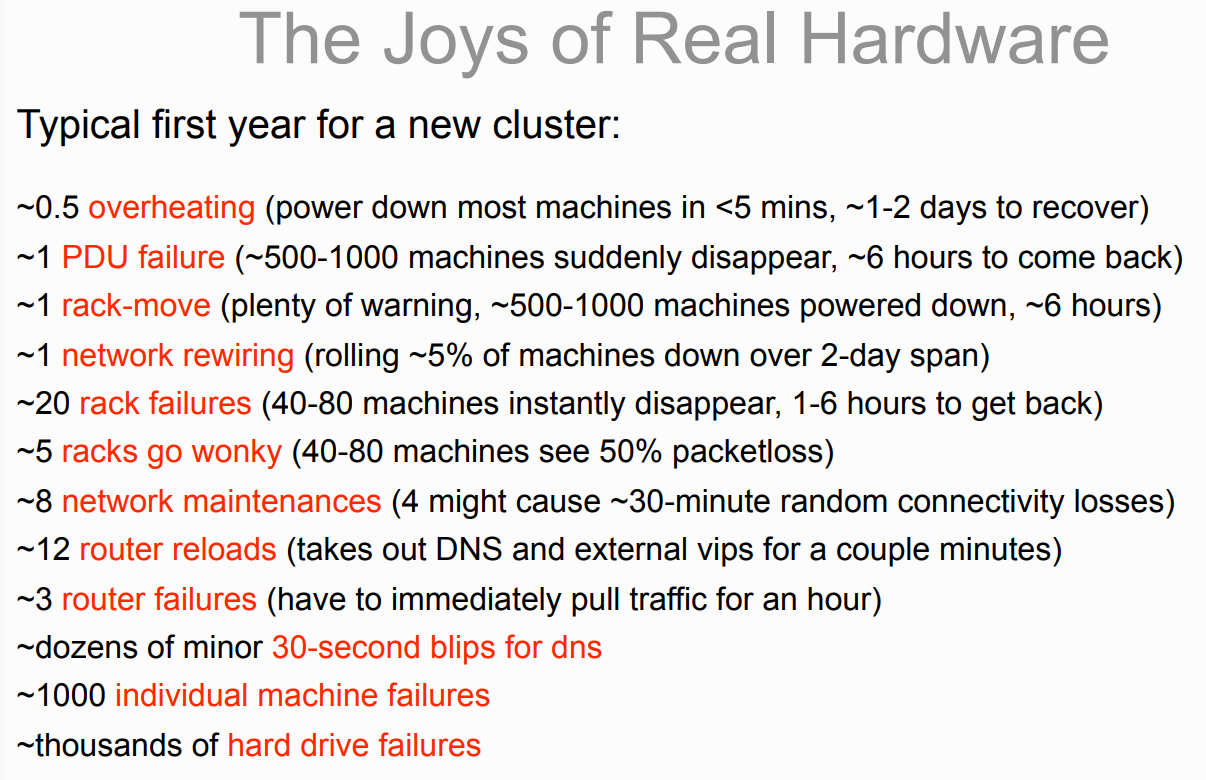
Source: [Jeff Dean](https://static.googleusercontent.com/media/research.google.com/en//people/jeff/stanford-295-talk.pdf)

We keep the same distributed Optuna study driver from above and swap in a different nested trial router for this section.

Each fold task now raises `InjectedTransientError` with probability `0.1`, using fresh system entropy on each task attempt.

- Demo A uses fold tasks with `max_retries=0`, so one transient fold error bubbles through the trial router to the driver and aborts the study.
- Demo B uses fold tasks with `max_retries=-1`, so Ray keeps replaying failed fold tasks until every logical trial finishes.


In [99]:
class InjectedTransientError(RuntimeError):
    pass


def run_flaky_fold_once(trial_id, fold_id, params, fold_bundle):
    t0 = time.perf_counter()
    result = fit_fold(fold_bundle, params)
    random_draw = random.SystemRandom().random()
    if random_draw > 0.9:
        raise InjectedTransientError(
            f"random transient fold failure: trial={trial_id} fold={fold_id} draw={random_draw:.3f}"
        )
    return {
        "trial_id": trial_id,
        "fold_id": fold_id,
        "worker_id": ray.get_runtime_context().get_worker_id(),
        "duration_sec": time.perf_counter() - t0,
        "random_draw": random_draw,
        **result,
    }


@ray.remote(num_cpus=1, max_retries=0, retry_exceptions=[InjectedTransientError])
def flaky_train_fold_remote_no_retry(trial_id, fold_id, params, fold_bundle):
    return run_flaky_fold_once(trial_id, fold_id, params, fold_bundle)


@ray.remote(num_cpus=1, max_retries=-1, retry_exceptions=[InjectedTransientError])
def flaky_train_fold_remote_infinite_retry(trial_id, fold_id, params, fold_bundle):
    return run_flaky_fold_once(trial_id, fold_id, params, fold_bundle)


@ray.remote(num_cpus=0, max_retries=0)
def run_flaky_cv_trial_remote_no_retry(trial_id, params, fold_bundle_refs):
    fold_result_refs = [
        flaky_train_fold_remote_no_retry.remote(trial_id, fold_id, params, fold_ref)
        for fold_id, fold_ref in enumerate(fold_bundle_refs)
    ]
    summary = summarize_parallel_fold_result_refs(fold_result_refs)
    return {
        "trial_id": trial_id,
        **summary,
    }


@ray.remote(num_cpus=0, max_retries=0)
def run_flaky_cv_trial_remote_infinite_retry(trial_id, params, fold_bundle_refs):
    fold_result_refs = [
        flaky_train_fold_remote_infinite_retry.remote(trial_id, fold_id, params, fold_ref)
        for fold_id, fold_ref in enumerate(fold_bundle_refs)
    ]
    summary = summarize_parallel_fold_result_refs(fold_result_refs)
    return {
        "trial_id": trial_id,
        **summary,
    }



In [100]:
print("Demo A: no fold-task retries.")

try:
    no_retry_study, no_retry_results = run_distributed_cv_study(
        fold_bundle_refs,
        n_trials=10,
        max_concurrent_trials=10,
        trial_runner=run_flaky_cv_trial_remote_no_retry,
    )
    print("This run completed without a random fold failure. Re-run the cell to see the driver-side abort path.")
    display(no_retry_results)
except ray.exceptions.RayTaskError as exc:
    print("A fold failure reached the driver, so the study aborted before all 10 trials completed.")
    print(type(exc.cause).__name__, exc.cause)


Demo A: no fold-task retries.
A fold failure reached the driver, so the study aborted before all 10 trials completed.
InjectedTransientError random transient fold failure: trial=9 fold=0 draw=0.919


In [101]:
print("Demo B: infinite fold-task retries.")

retrying_study, retrying_results = run_distributed_cv_study(
    fold_bundle_refs,
    n_trials=10,
    max_concurrent_trials=10,
    trial_runner=run_flaky_cv_trial_remote_infinite_retry,
)

print(f"Best retrying-study CV AUC: {retrying_study.best_value:.5f}")
display(retrying_results)


Demo B: infinite fold-task retries.


2026-03-27 14:27:26,446	ERROR worker.py:439 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::run_flaky_cv_trial_remote_no_retry() (pid=1248, ip=127.0.0.1)
  File "python\\ray\\_raylet.pyx", line 1818, in ray._raylet.execute_task
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3812079367.py", line 39, in run_flaky_cv_trial_remote_no_retry
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3224258079.py", line 19, in summarize_parallel_fold_result_refs
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\worker.py", line 2981, in get
    values, debugger_breakpoint 

(raylet) Task flaky_train_fold_remote_infinite_retry failed. There are infinite retries remaining, so the task will be retried. Error: User exception:
ray::flaky_train_fold_remote_infinite_retry() (pid=1288, ip=127.0.0.1)
  File "python\\ray\\_raylet.pyx", line 1818, in ray._raylet.execute_task
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3812079367.py", line 30, in flaky_train_fold_remote_infinite_retry
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3812079367.py", line 10, in run_flaky_fold_once
InjectedTransientError: random transient fold failure: trial=2 fold=0 draw=0.938
[driver] completion_rank=1 trial=4 score=0.99262
[driver] completion_rank=2 trial=3 score=0.97644


2026-03-27 14:27:26,879	ERROR worker.py:439 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::run_flaky_cv_trial_remote_no_retry() (pid=1532, ip=127.0.0.1)
  File "python\\ray\\_raylet.pyx", line 1818, in ray._raylet.execute_task
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3812079367.py", line 39, in run_flaky_cv_trial_remote_no_retry
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\3224258079.py", line 19, in summarize_parallel_fold_result_refs
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\client_mode_hook.py", line 104, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\.conda\envs\22971-ray\Lib\site-packages\ray\_private\worker.py", line 2981, in get
    values, debugger_breakpoint 

[driver] completion_rank=3 trial=5 score=0.99208
[driver] completion_rank=4 trial=9 score=0.99326
[driver] completion_rank=5 trial=6 score=0.99074
[driver] completion_rank=6 trial=7 score=0.99212
[driver] completion_rank=7 trial=8 score=0.99213
[driver] completion_rank=8 trial=1 score=0.99153
[driver] completion_rank=9 trial=0 score=0.99265
[driver] completion_rank=10 trial=2 score=0.99203
Best retrying-study CV AUC: 0.99326


,completion_rank,trial_id,score,best_iteration,max_depth,eta,subsample,colsample_bytree,lambda
0,1,4,0.992621,36,6,0.151514,0.784592,0.912212,0.002972
1,2,3,0.976444,41,2,0.010712,0.933048,0.911263,3.020290
2,3,5,0.992081,58,5,0.016284,0.977868,0.808739,0.045567
3,4,9,0.993259,29,5,0.020453,0.651571,0.726171,0.028500
4,5,6,0.990738,38,3,0.139199,0.782460,0.827374,0.001189
5,6,7,0.992120,45,5,0.080194,0.846774,0.977499,0.533680
6,7,8,0.992127,29,3,0.044213,0.879052,0.624090,0.464587
7,8,1,0.991526,35,5,0.044296,0.956709,0.985465,0.034180
8,9,0,0.992650,34,4,0.113873,0.841105,0.817953,0.049502
9,10,2,0.992034,19,5,0.060429,0.827218,0.970239,0.001924


## 4. Anti-pattern: duplicate writes

A common buggy pattern with retried tasks:
1. mutate cluster state (e.g. `counter.increment()`)
2. fail and retry
3. mutate same state again (another `counter.increment()`)
4. do not take into account previous mutation

We'll simulate this situation by moving the ownership of the Optuna study to an actor and have trial tasks report results to the actor.

In [102]:
REPORT_FAILURE_PROB = 0.5


class DirtyStudyActor:
    def __init__(self, seed=SEED):
        self.study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=seed),
        )
        self.open_trials = {}
        self.reported_trial_ids = set()
        self.report_sum = 0.0
        self.report_count = 0
        self.history = []

    def ask_trial(self):
        trial = self.study.ask()
        params = suggest_xgb_params(trial)
        self.open_trials[trial.number] = trial
        return {
            "trial_id": trial.number,
            "params": params,
        }

    def report_trial_result(self, trial_id, score, best_iteration):
        # Bug: retries replay these running totals even though the trial is only told once.
        self.report_sum += float(score)
        self.report_count += 1
        #
        self.history.append({"trial_id": trial_id, "score": float(score)})

        if trial_id not in self.reported_trial_ids:
            self.reported_trial_ids.add(trial_id)
            trial = self.open_trials[trial_id]
            trial.set_user_attr("best_iteration", int(best_iteration))
            self.study.tell(trial, float(score))

    def duplicate_trial_ids(self, history):
        counts = {}
        for item in history:
            trial_id = item["trial_id"]
            counts[trial_id] = counts.get(trial_id, 0) + 1
        return sorted([trial_id for trial_id, count in counts.items() if count > 1])

    def snapshot(self):
        unique_scores_by_trial = {}
        for item in self.history:
            unique_scores_by_trial[item["trial_id"]] = float(item["score"])
        final_unique_scores = list(unique_scores_by_trial.values())
        return {
            "completed_trial_count": len(self.reported_trial_ids),
            "report_attempt_count": self.report_count,
            "running_report_mean_score": float(self.report_sum / self.report_count) if self.report_count else float("nan"),
            "final_unique_mean_score": float(np.mean(final_unique_scores)) if final_unique_scores else float("nan"),
            "history": list(self.history),
            "duplicate_attempt_trials": self.duplicate_trial_ids(self.history),
        }


DirtyStudyActorBase = DirtyStudyActor
DirtyStudyActor = ray.remote(num_cpus=0)(DirtyStudyActor)


@ray.remote(num_cpus=0, max_retries=-1, retry_exceptions=[InjectedTransientError])
def run_trial_and_report_remote(trial_spec, fold_bundle_refs, study_actor, fail_after_report_prob=REPORT_FAILURE_PROB):
    cv_result = ray.get(
        run_cv_trial_remote.remote(
            trial_id=trial_spec["trial_id"],
            params=trial_spec["params"],
            fold_bundle_refs=fold_bundle_refs,
        )
    )

    ray.get(
        study_actor.report_trial_result.remote(
            trial_spec["trial_id"],
            cv_result["score"],
            cv_result["best_iteration"],
        )
    )

    random_draw = random.SystemRandom().random()
    if random_draw < fail_after_report_prob:
        raise InjectedTransientError(
            f"post-report transient failure: trial={trial_spec['trial_id']} draw={random_draw:.3f}"
        )


def run_actor_managed_study(study_actor, fold_bundle_refs, n_trials=6, max_concurrent_trials=3, fail_after_report_prob=REPORT_FAILURE_PROB):
    in_flight = []
    launched = 0

    def launch_one():
        trial_spec = ray.get(study_actor.ask_trial.remote())
        return run_trial_and_report_remote.remote(
            trial_spec,
            fold_bundle_refs,
            study_actor,
            fail_after_report_prob,
        )

    while launched < min(max_concurrent_trials, n_trials):
        in_flight.append(launch_one())
        launched += 1

    while in_flight:
        ready_refs, in_flight = ray.wait(in_flight, num_returns=1)
        ray.get(ready_refs[0])

        if launched < n_trials:
            in_flight.append(launch_one())
            launched += 1

    return ray.get(study_actor.snapshot.remote())


In [103]:
dirty_study_actor = DirtyStudyActor.remote(seed=SEED)
dirty_snapshot = run_actor_managed_study(
    dirty_study_actor,
    fold_bundle_refs,
    n_trials=6,
    max_concurrent_trials=3,
    fail_after_report_prob=REPORT_FAILURE_PROB,
)

dirty_snapshot


(raylet) Task run_trial_and_report_remote failed. There are infinite retries remaining, so the task will be retried. Error: User exception:
ray::run_trial_and_report_remote() (pid=28832, ip=127.0.0.1)
  File "python\\ray\\_raylet.pyx", line 1818, in ray._raylet.execute_task
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\2603802040.py", line 84, in run_trial_and_report_remote
InjectedTransientError: post-report transient failure: trial=0 draw=0.020


{'completed_trial_count': 6,
 'report_attempt_count': 11,
 'running_report_mean_score': 0.9879101661650137,
 'final_unique_mean_score': 0.9895595164812616,
 'history': [{'trial_id': 0, 'score': 0.9926504858637824},
  {'trial_id': 1, 'score': 0.9915259640328893},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 3, 'score': 0.9764444004748714},
  {'trial_id': 0, 'score': 0.9926504858637824},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 4, 'score': 0.9926208064019698},
  {'trial_id': 3, 'score': 0.9764444004748714},
  {'trial_id': 5, 'score': 0.9920810798927143},
  {'trial_id': 3, 'score': 0.9764444004748714},
  {'trial_id': 5, 'score': 0.9920810798927143}],
 'duplicate_attempt_trials': [0, 2, 3, 5]}

## 5. Solution: idempotency

The problematic method is `study_actor.report_trial_result`.

The fix: running `report_trial_result(trial_id, score, best_iteration)` multiple times should produce the same final actor state as running it once.

In [106]:

class SafeStudyActor(DirtyStudyActorBase):
    def __init__(self, seed=SEED):
        super().__init__(seed=seed)
        self.results_by_trial = {}

    def report_trial_result(self, trial_id, score, best_iteration):
        self.results_by_trial[trial_id] = {
            "score": float(score),
            "best_iteration": int(best_iteration),
        }
        self.history.append({"trial_id": trial_id, "score": float(score)})

        if trial_id not in self.reported_trial_ids:
            self.report_sum += float(score)
            self.report_count += 1
            self.reported_trial_ids.add(trial_id)
            trial = self.open_trials[trial_id]
            trial.set_user_attr("best_iteration", int(best_iteration))
            self.study.tell(trial, float(score))

    def snapshot(self):
        unique_scores = [result["score"] for result in self.results_by_trial.values()]
        return {
            "report_attempt_count": len(self.history),
            "unique_trial_count": len(self.results_by_trial),
            "running_report_mean_score": float(self.report_sum / self.report_count) if self.report_count else float("nan"),
            "final_unique_mean_score": float(np.mean(unique_scores)) if unique_scores else float("nan"),
            "history": list(self.history),
            "duplicate_attempt_trials": self.duplicate_trial_ids(self.history),
        }


SafeStudyActor = ray.remote(num_cpus=0)(SafeStudyActor)


In [107]:
safe_study_actor = SafeStudyActor.remote(seed=SEED)
safe_snapshot = run_actor_managed_study(
    safe_study_actor,
    fold_bundle_refs,
    n_trials=6,
    max_concurrent_trials=3,
    fail_after_report_prob=REPORT_FAILURE_PROB,
)

safe_snapshot


(raylet) Task run_trial_and_report_remote failed. There are infinite retries remaining, so the task will be retried. Error: User exception:
ray::run_trial_and_report_remote() (pid=1532, ip=127.0.0.1)
  File "python\\ray\\_raylet.pyx", line 1818, in ray._raylet.execute_task
  File "C:\Users\User\AppData\Local\Temp\ipykernel_4668\2603802040.py", line 84, in run_trial_and_report_remote
InjectedTransientError: post-report transient failure: trial=0 draw=0.080


{'report_attempt_count': 14,
 'unique_trial_count': 6,
 'running_report_mean_score': 0.9895595164812616,
 'final_unique_mean_score': 0.9895595164812616,
 'history': [{'trial_id': 0, 'score': 0.9926504858637824},
  {'trial_id': 1, 'score': 0.9915259640328893},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 0, 'score': 0.9926504858637822},
  {'trial_id': 3, 'score': 0.9764444004748714},
  {'trial_id': 1, 'score': 0.9915259640328893},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 3, 'score': 0.9764444004748714},
  {'trial_id': 4, 'score': 0.9926208064019698},
  {'trial_id': 5, 'score': 0.9920810798927143},
  {'trial_id': 1, 'score': 0.9915259640328893},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 2, 'score': 0.9920343622213427},
  {'trial_id': 2, 'score': 0.9920343622213427}],
 'duplicate_attempt_trials': [0, 1, 2, 3]}

## 6. Concept summary

1. **Local baseline**: start with one process and one Optuna study so later changes are easy to isolate.
2. **Distributed trials**: move whole trials into Ray tasks while the driver still owns `study.ask()` and `study.tell()`.
3. **Nested tasks**: let one trial fan out into parallel fold work.
4. **Explicit retries**: retries change program semantics, not just performance.
5. **Idempotent actor writes**: once retries can replay `report_trial_result(...)`, an attempt-based running average can drift, but the final unique average over logical trials should stay stable.


## 7. Optional exercise

1. Convert this notebook into a `distributed_hpo_job.py` script and run it on a Ray cluster.
2. Add pruning logic to the Optuna study (easier with actors).
3. Ship pruning logic to the trial task and have them prune without actor communication.
4. Compare 2 and 3: which pruning strategies still work well, what freshness of shared state they need, and how often do tasks communicate with actors.